In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.style.use("ggplot")

In [4]:
import os

BASE_DIR = r"C:\Users\sb231\OneDrive\Desktop\bluestock DA"

processed = os.path.join(BASE_DIR,"data","processed")

In [5]:
fund = pd.read_csv(os.path.join(processed,r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\DAY 1 — Project Setup + Data Ingestion (ETL) DONE TASK\data\processed\fund_master_clean.csv"))

nav = pd.read_csv(os.path.join(processed,r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Data Cleaning + SQL Database Design\bluestock DA\data\processed\nav_history.csv"))

performance = pd.read_csv(os.path.join(processed,r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Data Cleaning + SQL Database Design\bluestock DA\data\processed\scheme_performance.csv"))

benchmark = pd.read_csv(os.path.join(processed,r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\raw\10_benchmark_indices.csv"))

In [6]:
print(fund.shape)

print(nav.shape)

print(performance.shape)

print(benchmark.shape)

(40, 15)
(46000, 3)
(40, 19)
(8050, 3)


In [7]:
nav["date"] = pd.to_datetime(nav["date"])

In [8]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [9]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


In [10]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

In [11]:
nav.reset_index(
    drop=True,
    inplace=True
)

In [12]:
nav["daily_return"] = (

nav.groupby("amfi_code")["nav"]

.pct_change()

)

In [13]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [14]:
nav["daily_return"].isnull().sum()

np.int64(40)

In [15]:
nav = nav.dropna(
    subset=["daily_return"]
)

In [16]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

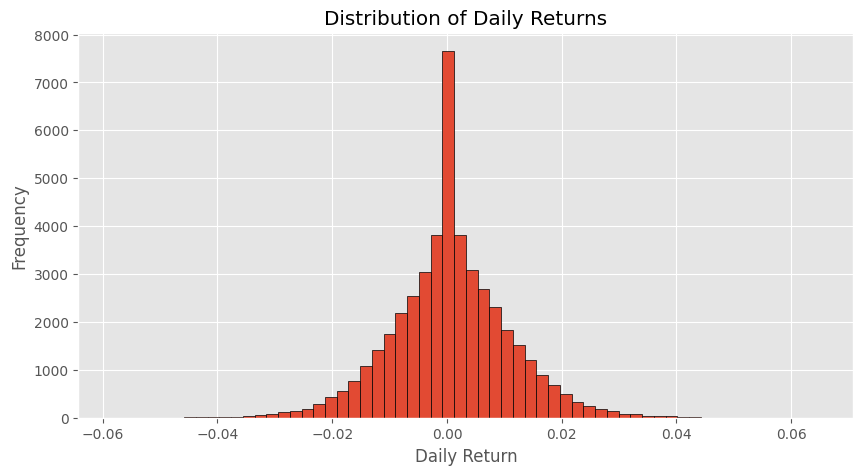

In [17]:
plt.figure(figsize=(10,5))

plt.hist(
    nav["daily_return"],
    bins=60,
    edgecolor="black"
)

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.title("Distribution of Daily Returns")

plt.show()

In [18]:
outliers = nav[

(nav["daily_return"]>0.20)

|

(nav["daily_return"]<-0.20)

]

In [19]:
outliers

,amfi_code,date,nav,daily_return


In [20]:
nav.to_csv(
    r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\DAY 1 — Project Setup + Data Ingestion (ETL) DONE TASK\data\processed\nav_history_clean.csv",
    index=False
)

In [21]:
print(processed)

C:\Users\sb231\OneDrive\Desktop\bluestock DA\data\processed


In [22]:
import os

print(os.path.exists(processed))

False


In [23]:
print(processed)

import os
print(os.path.exists(processed))

C:\Users\sb231\OneDrive\Desktop\bluestock DA\data\processed
False


In [24]:
nav.to_csv(

os.path.join(

processed,

r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\DAY 1 — Project Setup + Data Ingestion (ETL) DONE TASK\data\processed\nav_history_clean.csv",

),

index=False

)

In [25]:
performance = pd.read_csv(
    os.path.join(processed, r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\raw\07_scheme_performance.csv")
)

In [26]:
print(performance.columns.tolist())


['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [27]:
cagr_table = performance[
    [
        "amfi_code",
        "scheme_name",
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
]

In [28]:
cagr_table.head()

,amfi_code,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,119552,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,119598,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [29]:
cagr_table = cagr_table.rename(
    columns={
        "return_1yr_pct":"CAGR_1Y",
        "return_3yr_pct":"CAGR_3Y",
        "return_5yr_pct":"CAGR_5Y"
    }
)

In [30]:
cagr_table["Rank_3Y"] = (
    cagr_table["CAGR_3Y"]
    .rank(
        ascending=False
    )
)

In [31]:
cagr_table = cagr_table.sort_values(
    "Rank_3Y"
)

In [32]:
cagr_table.head(10)

,amfi_code,scheme_name,CAGR_1Y,CAGR_3Y,CAGR_5Y,Rank_3Y
2,119598,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67,1.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82,2.0
29,101207,ABSL Small Cap Fund - Regular - Growth,24.93,22.38,23.80,3.0
27,119095,Axis Small Cap Fund - Regular - Growth,21.97,20.98,22.62,4.0
17,118634,Nippon India Small Cap Fund - Regular - Growth,21.30,20.15,21.88,5.0
39,149324,DSP Small Cap Fund - Regular - Growth,20.20,20.08,20.61,6.0
21,120842,Kotak Emerging Equity Fund - Regular - Growth,17.12,18.23,17.75,7.0
12,120505,ICICI Pru Midcap Fund - Regular - Growth,14.02,18.08,17.55,8.0
38,149323,DSP Midcap Fund - Regular - Growth,14.12,17.16,19.00,9.0
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,15.43,16.58,17.69,10.0


In [33]:
cagr_table[
[
"CAGR_1Y",
"CAGR_3Y",
"CAGR_5Y"
]
].describe()

,CAGR_1Y,CAGR_3Y,CAGR_5Y
count,40.000000,40.000000,40.000000
mean,14.376000,14.089000,14.516750
std,4.883023,4.617253,4.454021
min,4.260000,5.140000,5.430000
25%,11.735000,12.035000,12.340000
50%,14.620000,14.205000,14.185000
75%,16.392500,15.882500,17.585000
max,24.930000,23.390000,23.800000


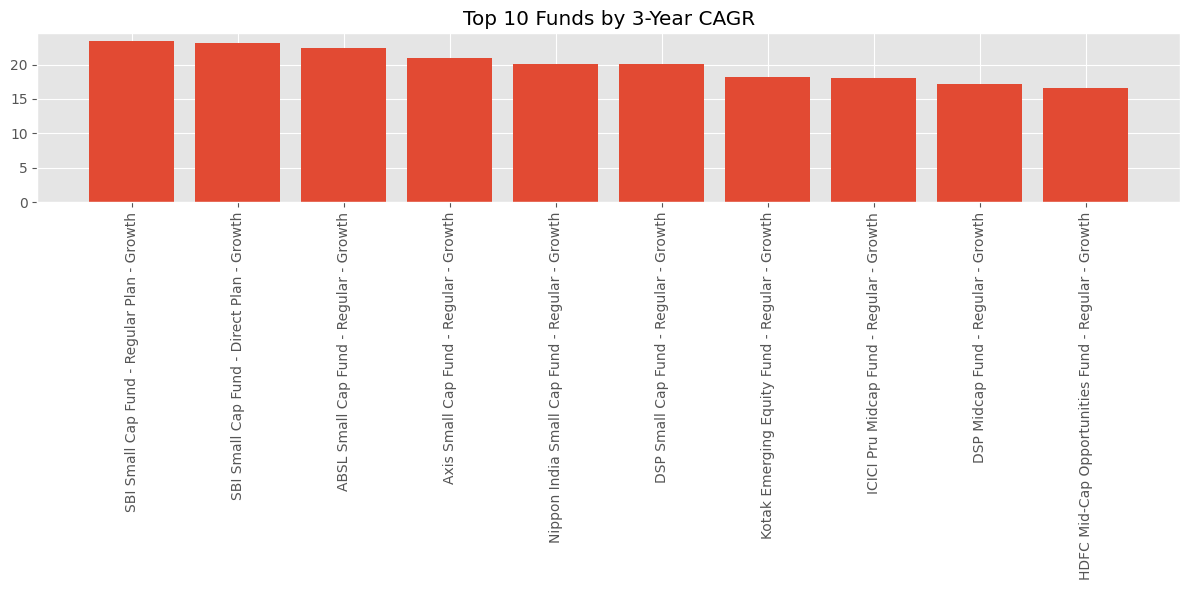

In [34]:
plt.figure(figsize=(12,6))

top10 = cagr_table.head(10)

plt.bar(
    top10["scheme_name"],
    top10["CAGR_3Y"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by 3-Year CAGR")

plt.tight_layout()

plt.show()

In [35]:
cagr_table.to_csv(
    os.path.join(
        processed,
        r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\processed\cagr_comparison.csv"
    ),
    index=False
)

In [36]:
print(performance.columns.tolist())


['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [37]:
performance["sharpe_ratio"].isnull().sum()

np.int64(0)

In [38]:
performance["sharpe_ratio"].describe()

count    40.000000
mean      1.361750
std       1.475805
min       0.800000
25%       0.865000
50%       0.925000
75%       0.985000
max       7.680000
Name: sharpe_ratio, dtype: float64

In [39]:
performance["Sharpe_Rank"] = (
    performance["sharpe_ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [40]:
sharpe_table = performance.sort_values(
    "Sharpe_Rank"
)

In [41]:
sharpe_table.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,Sharpe_Rank
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low,1.0
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low,2.0
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low,3.0
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low,4.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,5.0
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,0.37,1.33,2.38,4.0,-2.23,30030,0.55,4,Low,6.0
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate,7.0
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate,7.0
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate,8.0
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,Regular,15.84,14.00,14.70,13.14,0.86,0.88,1.00,1.68,14.0,-16.07,20909,1.51,4,Moderate,9.0


In [42]:
top10 = sharpe_table.head(10)

top10[
[
"scheme_name",
"sharpe_ratio",
"Sharpe_Rank"
]
]

,scheme_name,sharpe_ratio,Sharpe_Rank
14,ICICI Pru Liquid Fund - Regular - Growth,7.68,1.0
23,Kotak Liquid Fund - Regular - Growth,6.18,2.0
30,ABSL Liquid Fund - Regular - Growth,5.14,3.0
9,HDFC Short Term Debt Fund - Regular - Growth,1.84,4.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52,5.0
19,Nippon India Gilt Securities Fund - Regular - ...,1.33,6.0
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06,7.0
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06,7.0
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03,8.0
15,Nippon India Large Cap Fund - Regular - Growth,1.00,9.0


In [43]:
top10 = sharpe_table.head(10)

top10[
[
"scheme_name",
"sharpe_ratio",
"Sharpe_Rank"
]
]

,scheme_name,sharpe_ratio,Sharpe_Rank
14,ICICI Pru Liquid Fund - Regular - Growth,7.68,1.0
23,Kotak Liquid Fund - Regular - Growth,6.18,2.0
30,ABSL Liquid Fund - Regular - Growth,5.14,3.0
9,HDFC Short Term Debt Fund - Regular - Growth,1.84,4.0
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52,5.0
19,Nippon India Gilt Securities Fund - Regular - ...,1.33,6.0
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06,7.0
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06,7.0
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03,8.0
15,Nippon India Large Cap Fund - Regular - Growth,1.00,9.0


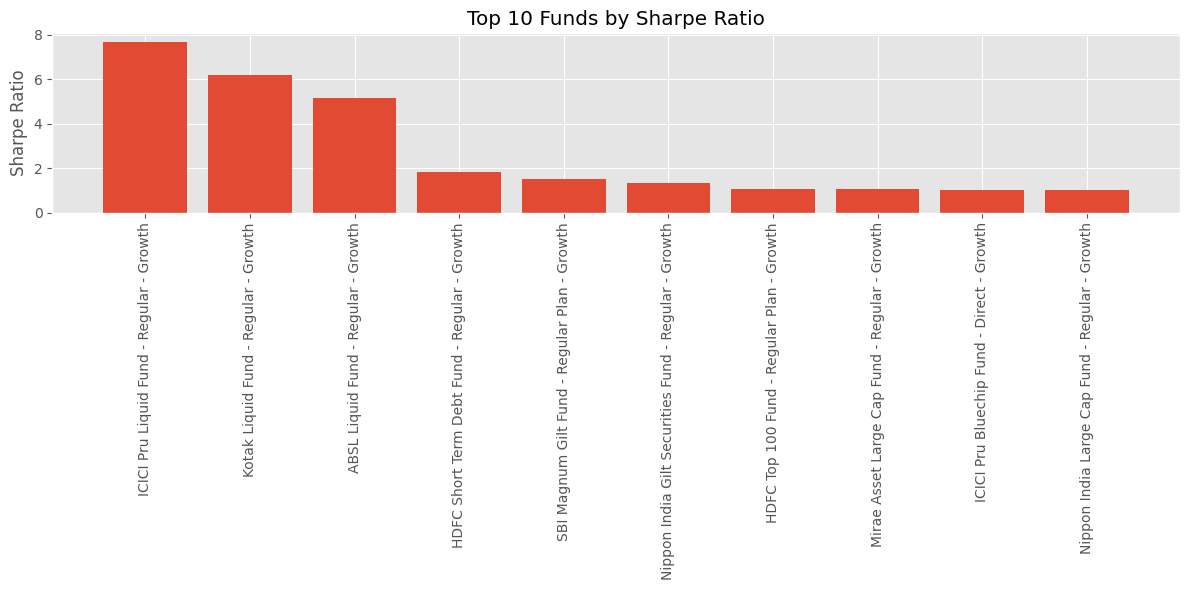

In [44]:
plt.figure(figsize=(12,6))

plt.bar(
    top10["scheme_name"],
    top10["sharpe_ratio"]
)

plt.xticks(rotation=90)

plt.ylabel("Sharpe Ratio")

plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.show()

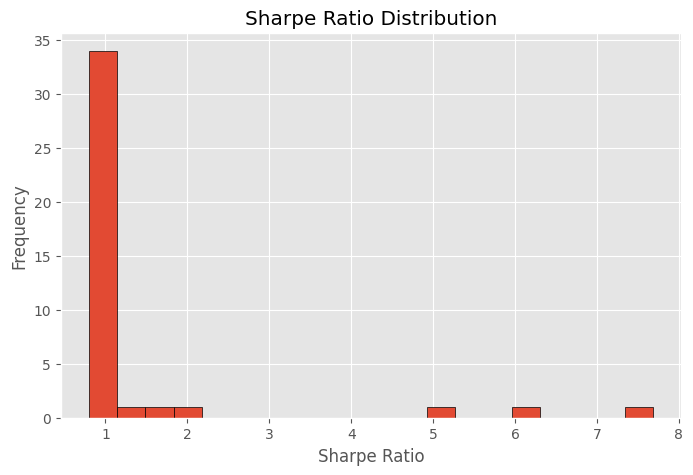

In [45]:
plt.figure(figsize=(8,5))

plt.hist(
    performance["sharpe_ratio"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Sharpe Ratio")

plt.ylabel("Frequency")

plt.title("Sharpe Ratio Distribution")

plt.show()

In [46]:
sharpe_table.to_csv(
    os.path.join(
        processed,
        r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\processed\sharp_ranking.csv"
    ),
    index=False
)

In [47]:
performance["sortino_ratio"].isnull().sum()

np.int64(0)

In [48]:
performance["sortino_ratio"].describe()

count    40.000000
mean      2.082500
std       2.203144
min       1.030000
25%       1.270000
50%       1.445000
75%       1.637500
max      10.370000
Name: sortino_ratio, dtype: float64

In [49]:
performance["Sortino_Rank"] = (
    performance["sortino_ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [50]:
sortino_table = performance.sort_values(
    "Sortino_Rank"
)

In [51]:
sortino_table.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,Sharpe_Rank,Sortino_Rank
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,7.68,10.37,0.5,-2.62,39116,0.74,5,Low,1.0,1.0
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,...,6.18,9.70,0.5,-3.81,27623,0.60,3,Low,2.0,2.0
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,...,5.14,8.76,0.5,-3.66,38995,0.79,5,Low,3.0,3.0
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,1.84,2.79,4.0,-6.01,27953,0.56,3,Low,4.0,4.0
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,...,1.33,2.38,4.0,-2.23,30030,0.55,4,Low,6.0,5.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,5.0,6.0
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate,7.0,7.0
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,Regular,15.84,14.00,14.70,13.14,0.86,...,1.00,1.68,14.0,-16.07,20909,1.51,4,Moderate,9.0,8.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,14.0,9.0
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate,7.0,10.0


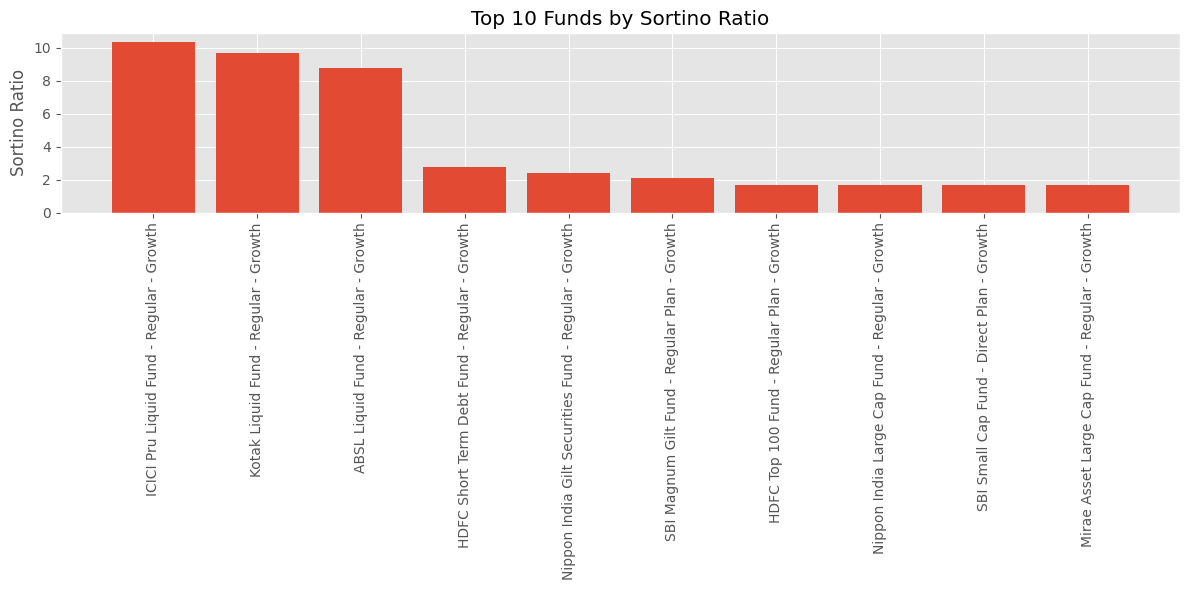

In [52]:
plt.figure(figsize=(12,6))

top10 = sortino_table.head(10)

plt.bar(
    top10["scheme_name"],
    top10["sortino_ratio"]
)

plt.xticks(rotation=90)

plt.ylabel("Sortino Ratio")

plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.show()

In [53]:
sortino_table.to_csv(
    os.path.join(
        processed,
        r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\processed\sortino_ranking.csv"
    ),
    index=False
)

In [54]:
print("Missing Alpha :", performance["alpha"].isnull().sum())

print("Missing Beta :", performance["beta"].isnull().sum())

Missing Alpha : 0
Missing Beta : 0


In [55]:
performance[["alpha","beta"]].describe()

,alpha,beta
count,40.000000,40.000000
mean,1.253500,0.873250
std,0.447412,0.224846
min,0.510000,0.220000
25%,0.887500,0.890000
50%,1.205000,0.960000
75%,1.700000,1.000000
max,1.980000,1.040000


In [56]:
performance["Alpha_Rank"] = (
    performance["alpha"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [57]:
performance["Beta_Rank"] = (
    performance["beta"]
    .rank(
        ascending=True,
        method="dense"
    )
)

In [58]:
alpha_beta = performance[
[
"amfi_code",
"scheme_name",
"alpha",
"beta",
"Alpha_Rank",
"Beta_Rank"
]
]

In [59]:
alpha_beta.head()

,amfi_code,scheme_name,alpha,beta,Alpha_Rank,Beta_Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89,28.0,9.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87,8.0,7.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89,18.0,9.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04,20.0,22.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22,11.0,1.0


In [60]:
top_alpha = alpha_beta.sort_values(
    "Alpha_Rank"
)

top_alpha.head(10)

,amfi_code,scheme_name,alpha,beta,Alpha_Rank,Beta_Rank
9,100025,HDFC Short Term Debt Fund - Regular - Growth,1.98,0.44,1.0,5.0
21,120842,Kotak Emerging Equity Fund - Regular - Growth,1.91,1.00,2.0,19.0
22,120843,Kotak Flexicap Fund - Regular - Growth,1.85,0.95,3.0,14.0
14,120507,ICICI Pru Liquid Fund - Regular - Growth,1.85,0.26,3.0,2.0
29,101207,ABSL Small Cap Fund - Regular - Growth,1.84,0.97,4.0,16.0
37,149322,DSP Top 100 Equity Fund - Regular - Growth,1.82,0.91,5.0,11.0
18,118635,Nippon India ETF Nifty 50 BeES,1.80,1.04,6.0,22.0
33,102887,UTI Flexi Cap Fund - Regular - Growth,1.79,1.00,7.0,19.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87,8.0,7.0
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,1.70,0.99,9.0,18.0


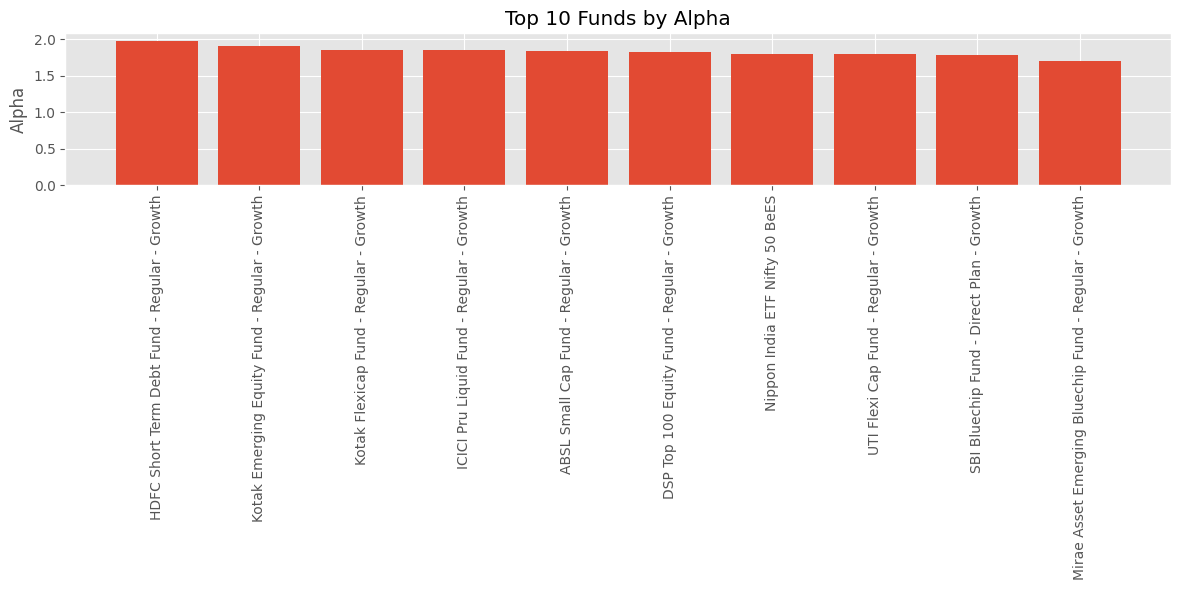

In [61]:
plt.figure(figsize=(12,6))

top10 = top_alpha.head(10)

plt.bar(
    top10["scheme_name"],
    top10["alpha"]
)

plt.xticks(rotation=90)

plt.ylabel("Alpha")

plt.title("Top 10 Funds by Alpha")

plt.tight_layout()

plt.show()

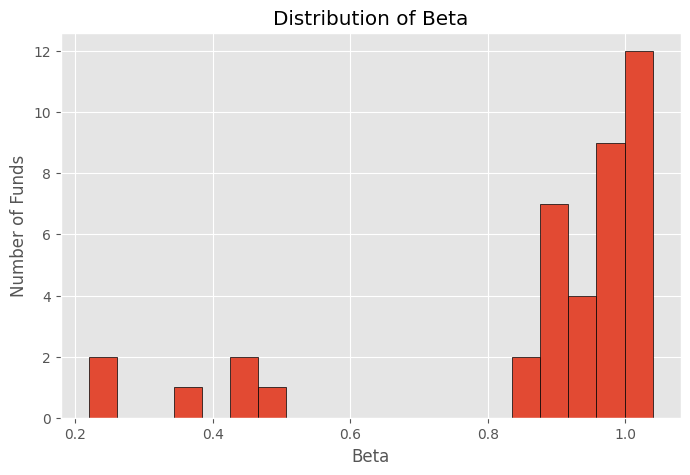

In [62]:
plt.figure(figsize=(8,5))

plt.hist(
    performance["beta"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Beta")

plt.ylabel("Number of Funds")

plt.title("Distribution of Beta")

plt.show()

In [63]:
alpha_beta.to_csv(
    os.path.join(
        processed,
        r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\processed\alpha_beta.csv"
    ),
    index=False
)

In [64]:
print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'Sharpe_Rank', 'Sortino_Rank', 'Alpha_Rank', 'Beta_Rank']


In [65]:
performance["Drawdown_Rank"] = (
    performance["max_drawdown_pct"]
    .rank(
        ascending=True,
        method="dense"
    )
)

In [66]:
drawdown_table = performance[
[
"amfi_code",
"scheme_name",
"max_drawdown_pct",
"Drawdown_Rank"
]
]

In [67]:
drawdown_table = drawdown_table.sort_values(
    "Drawdown_Rank"
)

In [68]:
drawdown_table.head(10)


,amfi_code,scheme_name,max_drawdown_pct,Drawdown_Rank
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,-33.50,1.0
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,-33.15,2.0
26,119094,Axis Midcap Fund - Regular - Growth,-32.38,3.0
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,-32.22,4.0
17,118634,Nippon India Small Cap Fund - Regular - Growth,-30.87,5.0
24,119092,Axis Bluechip Fund - Regular - Growth,-27.54,6.0
38,149323,DSP Midcap Fund - Regular - Growth,-26.99,7.0
18,118635,Nippon India ETF Nifty 50 BeES,-26.75,8.0
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,-26.59,9.0
10,120503,ICICI Pru Bluechip Fund - Regular - Growth,-25.91,10.0


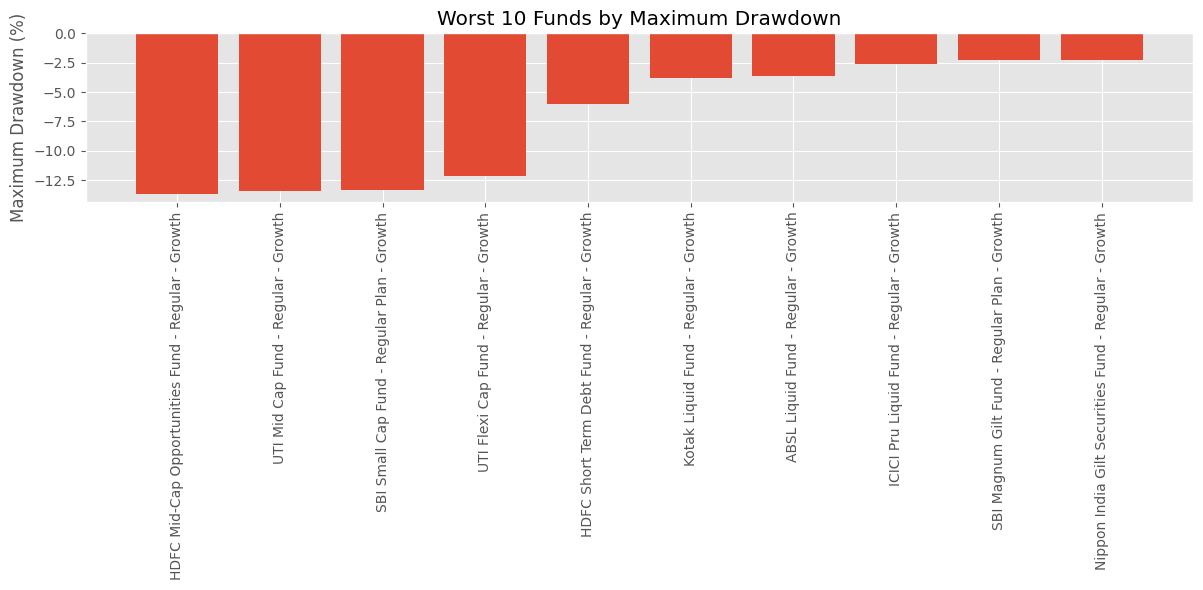

In [69]:
plt.figure(figsize=(12,6))

worst = drawdown_table.tail(10)

plt.bar(
    worst["scheme_name"],
    worst["max_drawdown_pct"]
)

plt.xticks(rotation=90)

plt.ylabel("Maximum Drawdown (%)")

plt.title("Worst 10 Funds by Maximum Drawdown")

plt.tight_layout()

plt.show()

In [70]:
drawdown_table.to_csv(
    os.path.join(
        processed,
        r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\processed\max_drawdown_ranking..csv"
    ),
    index=False
)

In [71]:
performance["Return_Rank"] = (
    performance["return_3yr_pct"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [72]:
performance["Sharpe_Rank"] = (
    performance["sharpe_ratio"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [73]:
performance["Alpha_Rank"] = (
    performance["alpha"]
    .rank(
        ascending=False,
        method="dense"
    )
)

In [74]:
performance["Expense_Rank"] = (
    performance["expense_ratio_pct"]
    .rank(
        ascending=True,
        method="dense"
    )
)

In [75]:
performance["Drawdown_Rank"] = (
    performance["max_drawdown_pct"]
    .rank(
        ascending=True,
        method="dense"
    )
)

In [76]:
performance["Fund_Score"] = (

0.30 * performance["Return_Rank"]

+

0.25 * performance["Sharpe_Rank"]

+

0.20 * performance["Alpha_Rank"]

+

0.15 * performance["Expense_Rank"]

+

0.10 * performance["Drawdown_Rank"]

)

In [77]:
performance["Fund_Score"] = (
    (
        performance["Fund_Score"].max()
        -
        performance["Fund_Score"]
    )
    /
    (
        performance["Fund_Score"].max()
        -
        performance["Fund_Score"].min()
    )
) * 100

In [78]:
performance = performance.sort_values(
    "Fund_Score",
    ascending=False
)

In [79]:
performance[
[
"scheme_name",
"Fund_Score"
]
].head(10)

,scheme_name,Fund_Score
3,SBI Small Cap Fund - Direct Plan - Growth,100.000000
21,Kotak Emerging Equity Fund - Regular - Growth,94.936709
29,ABSL Small Cap Fund - Regular - Growth,94.620253
22,Kotak Flexicap Fund - Regular - Growth,91.772152
2,SBI Small Cap Fund - Regular Plan - Growth,80.379747
34,Mirae Asset Large Cap Fund - Regular - Growth,72.151899
12,ICICI Pru Midcap Fund - Regular - Growth,71.202532
35,Mirae Asset Emerging Bluechip Fund - Regular -...,68.037975
9,HDFC Short Term Debt Fund - Regular - Growth,63.607595
26,Axis Midcap Fund - Regular - Growth,62.658228


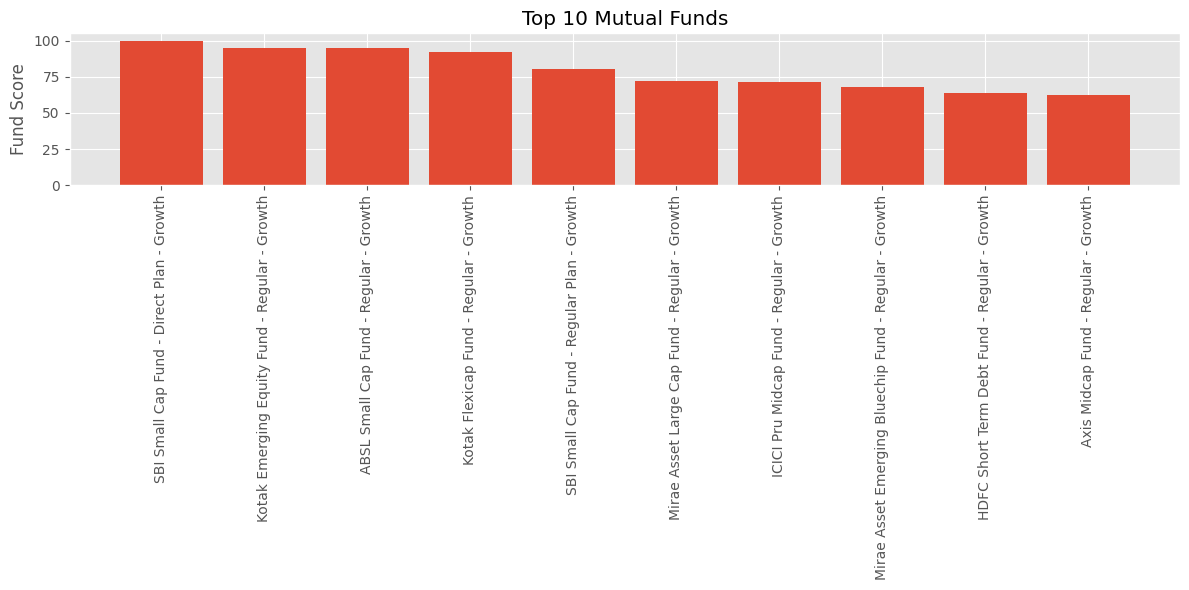

In [80]:
top10 = performance.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["scheme_name"],
    top10["Fund_Score"]
)

plt.xticks(rotation=90)

plt.ylabel("Fund Score")

plt.title("Top 10 Mutual Funds")

plt.tight_layout()

plt.show()

In [81]:
performance.to_csv(
    os.path.join(
        processed,
        r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\processed\fund_scorecard.csv"
    ),
    index=False
)

In [82]:
benchmark = pd.read_csv(
    os.path.join(
        processed,
        r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\raw\10_benchmark_indices.csv"
    )
)

In [83]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [84]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [85]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [86]:
print(nifty50.shape)
print(nifty100.shape)

(1150, 3)
(1150, 3)


In [87]:
nifty50["date"] = pd.to_datetime(nifty50["date"])
nifty100["date"] = pd.to_datetime(nifty100["date"])

nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

In [88]:
nifty50["daily_return"] = nifty50["close_value"].pct_change()
nifty100["daily_return"] = nifty100["close_value"].pct_change()

In [89]:
nifty50["normalized"] = (
    100 * nifty50["close_value"] / nifty50["close_value"].iloc[0]
)

nifty100["normalized"] = (
    100 * nifty100["close_value"] / nifty100["close_value"].iloc[0]
)

In [90]:
print(nifty50.shape)
print(nifty50.head())

(1150, 5)
        date index_name  close_value  daily_return  normalized
0 2022-01-03    NIFTY50     17492.79           NaN  100.000000
1 2022-01-04    NIFTY50     17689.64      0.011253  101.125321
2 2022-01-05    NIFTY50     17835.05      0.008220  101.956578
3 2022-01-06    NIFTY50     17878.51      0.002437  102.205023
4 2022-01-07    NIFTY50     17759.15     -0.006676  101.522684


In [91]:
print(benchmark["index_name"].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [92]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY 50"
]

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY 100"
]

In [93]:
print(nifty50.shape)
print(nifty100.shape)

(0, 3)
(0, 3)


In [94]:
print(benchmark.columns.tolist())


['date', 'index_name', 'close_value']


In [95]:
print(benchmark["index_name"].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [96]:
benchmark["index_name"] == "NIFTY50"

0        True
1        True
2        True
3        True
4        True
        ...  
8045    False
8046    False
8047    False
8048    False
8049    False
Name: index_name, Length: 8050, dtype: bool

In [97]:
benchmark["index_name"] = benchmark["index_name"].str.strip()

In [98]:
benchmark["index_name"] = benchmark["index_name"].str.strip().str.upper()


print(benchmark["index_name"].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [99]:
nifty50["normalized"] = (

100*

nifty50["close_value"]

/

nifty50["close_value"].iloc[0]

)

IndexError: single positional indexer is out-of-bounds

In [100]:
print(benchmark["index_name"].unique())

['NIFTY50' 'NIFTY100' 'NIFTY_MIDCAP150' 'BSE_SMALLCAP' 'NIFTY500'
 'CRISIL_LIQUID' 'CRISIL_GILT']


In [101]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

In [102]:
print(benchmark.shape)

(8050, 3)


In [103]:
print(nifty50.shape)
print(nifty100.shape)

(1150, 3)
(1150, 3)


In [104]:
nifty50["date"] = pd.to_datetime(nifty50["date"])

nifty100["date"] = pd.to_datetime(nifty100["date"])

In [105]:
nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

In [106]:
nifty50["daily_return"] = nifty50["close_value"].pct_change()

nifty100["daily_return"] = nifty100["close_value"].pct_change()

In [107]:
nifty50["normalized"] = (
    100 * nifty50["close_value"] / nifty50["close_value"].iloc[0]
)

nifty100["normalized"] = (
    100 * nifty100["close_value"] / nifty100["close_value"].iloc[0]
)

/resume here


In [108]:
print(nifty50.head())

print(nifty100.head())

        date index_name  close_value  daily_return  normalized
0 2022-01-03    NIFTY50     17492.79           NaN  100.000000
1 2022-01-04    NIFTY50     17689.64      0.011253  101.125321
2 2022-01-05    NIFTY50     17835.05      0.008220  101.956578
3 2022-01-06    NIFTY50     17878.51      0.002437  102.205023
4 2022-01-07    NIFTY50     17759.15     -0.006676  101.522684
           date index_name  close_value  daily_return  normalized
1150 2022-01-03   NIFTY100     17778.24           NaN  100.000000
1151 2022-01-04   NIFTY100     17537.52     -0.013540   98.645985
1152 2022-01-05   NIFTY100     17607.73      0.004003   99.040906
1153 2022-01-06   NIFTY100     17556.05     -0.002935   98.750214
1154 2022-01-07   NIFTY100     17664.02      0.006150   99.357529


In [109]:
nav = nav.sort_values(["amfi_code", "date"])

nav["normalized_nav"] = (
    nav.groupby("amfi_code")["nav"]
       .transform(lambda x: 100 * x / x.iloc[0])
)


In [110]:
top5 = performance.sort_values(
    "Fund_Score",
    ascending=False
).head(5)

print(top5[["amfi_code", "scheme_name"]])

    amfi_code                                    scheme_name
3      119599      SBI Small Cap Fund - Direct Plan - Growth
21     120842  Kotak Emerging Equity Fund - Regular - Growth
29     101207         ABSL Small Cap Fund - Regular - Growth
22     120843         Kotak Flexicap Fund - Regular - Growth
2      119598     SBI Small Cap Fund - Regular Plan - Growth


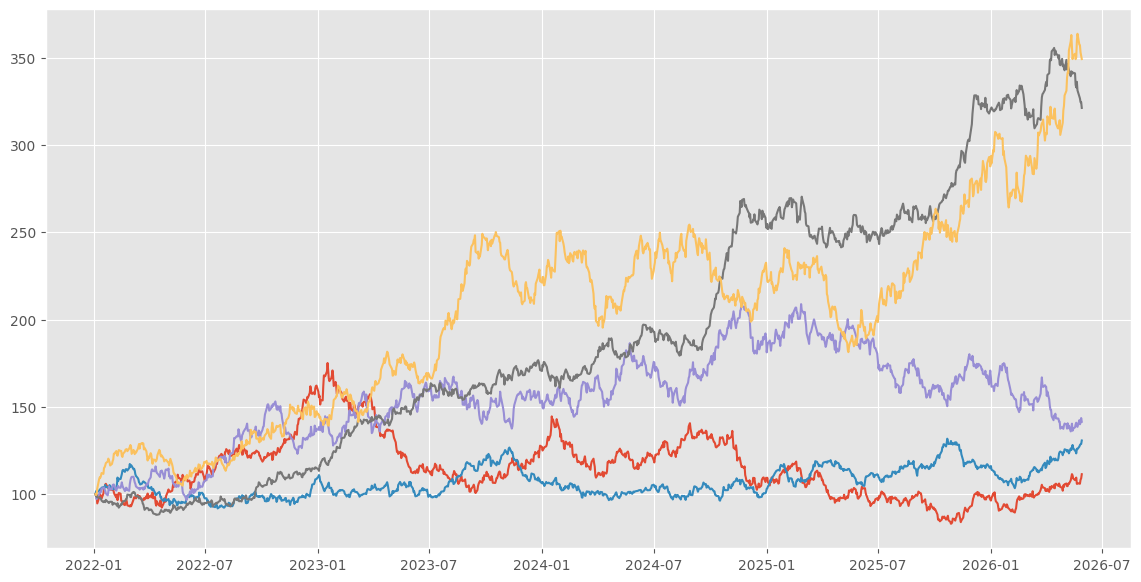

In [111]:
plt.figure(figsize=(14, 7))

for code in top5["amfi_code"]:

    temp = nav[nav["amfi_code"] == code]

    plt.plot(
        temp["date"],
        temp["normalized_nav"],
        label=temp["scheme_name"].iloc[0] if "scheme_name" in temp.columns else str(code)
    )

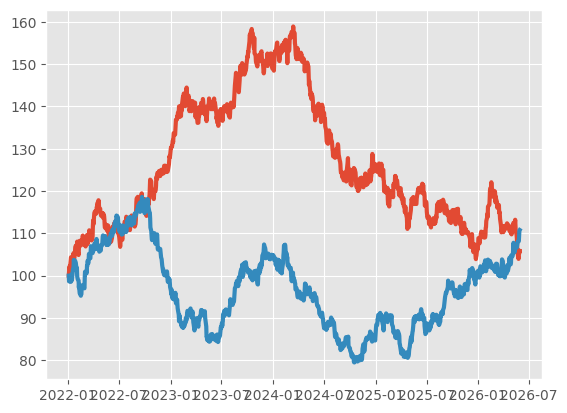

In [112]:
plt.plot(
    nifty50["date"],
    nifty50["normalized"],
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    linewidth=3,
    label="NIFTY100"
)

C:\Users\sb231\AppData\Local\Temp\ipykernel_18560\1297129046.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


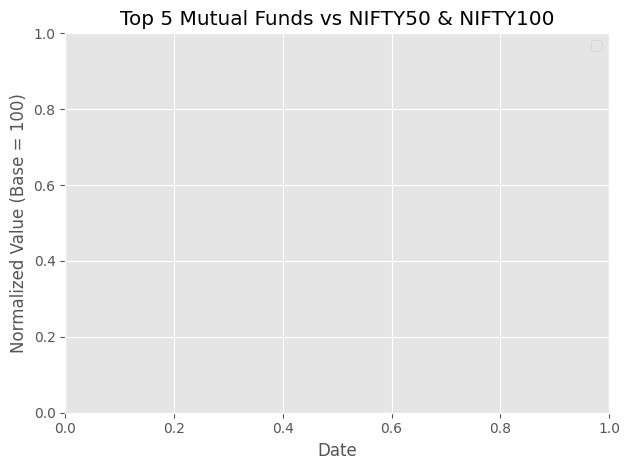

In [113]:
plt.title("Top 5 Mutual Funds vs NIFTY50 & NIFTY100")

plt.xlabel("Date")

plt.ylabel("Normalized Value (Base = 100)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [114]:
import os

reports = os.path.join(BASE_DIR, "reports")

os.makedirs(reports, exist_ok=True)

plt.savefig(
    os.path.join(reports, "benchmark_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [115]:
print(nav["date"].dtype)
print(nifty50["date"].dtype)

print(nav["normalized_nav"].head())
print(nifty50["normalized"].head())

datetime64[ns]
datetime64[ns]
1    100.000000
2    101.286515
3    100.134130
4    100.012968
5     99.148995
Name: normalized_nav, dtype: float64
0    100.000000
1    101.125321
2    101.956578
3    102.205023
4    101.522684
Name: normalized, dtype: float64


In [116]:
tracking_results = []

In [117]:
for code in top5["amfi_code"]:

    # Get one fund
    fund = nav[nav["amfi_code"] == code].copy()

    # Keep only required columns
    fund = fund[["date", "daily_return"]]

    # Merge with benchmark returns
    merged = pd.merge(
        fund,
        nifty100[["date", "daily_return"]],
        on="date",
        suffixes=("_fund", "_benchmark")
    )

    # Calculate Tracking Error
    tracking_error = (
        (merged["daily_return_fund"] -
         merged["daily_return_benchmark"]).std()
        * np.sqrt(252)
    )

    tracking_results.append({
        "amfi_code": code,
        "tracking_error": tracking_error
    })

In [118]:
tracking_df = pd.DataFrame(tracking_results)

tracking_df

,amfi_code,tracking_error
0,119599,0.277135
1,120842,0.219169
2,101207,0.292117
3,120843,0.206425
4,119598,0.283881


In [119]:
tracking_df = tracking_df.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

tracking_df

,amfi_code,tracking_error,scheme_name
0,119599,0.277135,SBI Small Cap Fund - Direct Plan - Growth
1,120842,0.219169,Kotak Emerging Equity Fund - Regular - Growth
2,101207,0.292117,ABSL Small Cap Fund - Regular - Growth
3,120843,0.206425,Kotak Flexicap Fund - Regular - Growth
4,119598,0.283881,SBI Small Cap Fund - Regular Plan - Growth


In [120]:
tracking_df = tracking_df.sort_values(
    "tracking_error"
)

tracking_df

,amfi_code,tracking_error,scheme_name
3,120843,0.206425,Kotak Flexicap Fund - Regular - Growth
1,120842,0.219169,Kotak Emerging Equity Fund - Regular - Growth
0,119599,0.277135,SBI Small Cap Fund - Direct Plan - Growth
4,119598,0.283881,SBI Small Cap Fund - Regular Plan - Growth
2,101207,0.292117,ABSL Small Cap Fund - Regular - Growth


In [121]:
tracking_df.to_csv(
    os.path.join(
        BASE_DIR,
        "reports",
        r"C:\Users\sb231\OneDrive\Desktop\mutual-funds-analysis\Fund Performance Analytics\data\processed\tracking_error.csv"
    ),
    index=False
)